# Modelado de Series Temporales: SARIMA

En base al análisis exploratorio previo (test ADF estacionario, pero con fuerte estacionalidad anual en enfermedades respiratorias), aplicaremos el modelo **SARIMA** (Seasonal Autoregressive Integrated Moving Average).

Separaremos la serie temporal dejando el último año (52 semanas) como conjunto de prueba (test set) para evaluar qué tan bien el modelo puede predecir "el futuro" comparado con los datos reales que ya tenemos.

In [67]:
%pip install pandas numpy matplotlib statsmodels scikit-learn pmdarima

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings

warnings.filterwarnings('ignore')

def get_date_from_iso_week(year, week):
    date_str = f'{year}-W{week:02d}-1' 
    try:
        return datetime.strptime(date_str, '%G-W%V-%u')
    except ValueError:
        return datetime(year, 12, 31)

## 1. Carga y Preparación de la Variable Objetivo

Se aísla la variable a predecir (`NumTotal`), agrupándola por semana epidemiológica. 
Se aplica un recorte del historial hasta el **10 de mayo de 2026** para evitar que las métricas de error se distorsionen al evaluar contra los meses de invierno de 2026, los cuales aún no cuentan con datos reales en el sistema.

In [69]:
df = pd.read_parquet('../dataset/at_urg_respiratorio_2026-05-10.parquet')

df['Fecha'] = df.apply(lambda row: get_date_from_iso_week(int(row['Anio']), int(row['SemanaEstadistica'])), axis=1)

ts_df = df.groupby('Fecha')['NumTotal'].sum().reset_index()
ts_df.set_index('Fecha', inplace=True)
ts_df.sort_index(inplace=True)
ts_df = ts_df.asfreq('W-MON')
ts_df['NumTotal'] = ts_df['NumTotal'].interpolate(method='linear')

ts_df = ts_df[ts_df.index <= '2026-05-10']

print("=== Variable objetivo preparada ===")
print(f"Total de registros (filtrados hasta mayo 2026): {len(ts_df)}")
print(ts_df.tail(3))

=== Variable objetivo preparada ===
Total de registros (filtrados hasta mayo 2026): 645
                 NumTotal
Fecha                    
2026-04-20  188123.000000
2026-04-27   34384.000000
2026-05-04   34817.228571


## 2. Integración de Variables Ambientales (Exógenas)

Los estudios medicos indican que los virus respiratorios tienen un fuerte componente estacional ligado al clima y la contaminación. 

En esta sección se integran 5 variables exógenas al modelo:
* Temperatura promedio.
* Radiación solar.
* Precipitaciones.
* Humedad relativa.
* Calidad del aire (PM2.5 y PM10).

*(Los datos históricos faltantes en los sensores satelitales más antiguos han sido tratados mediante interpolación direccional).*

In [70]:
# Lista con las rutas y las columnas numéricas de cada archivo
archivos_exog = [
    ('variables_exogenas/csv/temperatura_semanal_regiones_2014_2026.csv', ['temp_promedio_semanal']),
    ('variables_exogenas/csv/radiacion_semanal_regiones_2014_2026.csv', ['radiacion_solar_media_MJ_m2']),
    ('variables_exogenas/csv/precipitacion_semanal_regiones_2014_2026.csv', ['precipitacion_promedio_diario_mm']),
    ('variables_exogenas/csv/humedad_semanal_regiones_2014_2026.csv', ['humedad_relativa_promedio_porcentaje']),
    ('variables_exogenas/csv/calidad_aire_semanal_regiones_2014_2026.csv', ['pm2_5_ug_m3', 'pm10_ug_m3'])
]

exog_cols = []

print("Procesando e integrando variables exógenas...")

for ruta, columnas in archivos_exog:
    df_tmp = pd.read_csv(ruta)
    
    for col in columnas:
        df_tmp[col] = pd.to_numeric(df_tmp[col], errors='coerce')
        exog_cols.append(col)
    
    df_tmp['Fecha'] = df_tmp.apply(lambda row: get_date_from_iso_week(int(row['anio']), int(row['semana'])), axis=1)
    
    df_grp = df_tmp.groupby('Fecha')[columnas].mean()
    
    ts_df = ts_df.join(df_grp)

ts_df[exog_cols] = ts_df[exog_cols].interpolate(method='linear', limit_direction='both')

print("\n=== Dataset Final Listo ===")
print(f"Variables exógenas añadidas: {exog_cols}")
print(ts_df.tail(3))

Procesando e integrando variables exógenas...

=== Dataset Final Listo ===
Variables exógenas añadidas: ['temp_promedio_semanal', 'radiacion_solar_media_MJ_m2', 'precipitacion_promedio_diario_mm', 'humedad_relativa_promedio_porcentaje', 'pm2_5_ug_m3', 'pm10_ug_m3']
                 NumTotal  temp_promedio_semanal  radiacion_solar_media_MJ_m2  \
Fecha                                                                           
2026-04-20  188123.000000              12.720625                    14.110625   
2026-04-27   34384.000000              12.436250                    12.085625   
2026-05-04   34817.228571              12.326875                    10.735625   

            precipitacion_promedio_diario_mm  \
Fecha                                          
2026-04-20                          1.376875   
2026-04-27                          2.396250   
2026-05-04                          4.325000   

            humedad_relativa_promedio_porcentaje  pm2_5_ug_m3  pm10_ug_m3  
Fecha      

## 3. Entrenamiento y Validación Cruzada (Rolling Window)

Para garantizar que las métricas de error sean robustas y no producto del azar de un año específico, se utiliza la validación por **Rolling Window**.



**Parámetros Base del Modelo:** Optimizados previamente mediante un *Grid Search* aislando la tendencia estacional:
* **Order (p,d,q):** (1, 0, 0)
* **Seasonal (P,D,Q,m):** (0, 1, 0, 52)

## 4. Resumen de Métricas de Rendimiento

Se consolidan los errores de todas las ventanas evaluadas (2023, 2024, 2025 y principio de 2026) para obtener el rendimiento real promedio del algoritmo bajo condiciones temporales cambiantes.

In [71]:
start_train_year = 2014
start_test_year = 2023
end_dataset_year = 2026

resultados_rolling = []
predicciones_totales = []
ic_totales = []

print("=== EJECUTANDO VALIDACIÓN POR ROLLING WINDOW CON EXÓGENAS ===")

for test_year in range(start_test_year, end_dataset_year + 1):
    # Separar temporalmente Train y Test
    train = ts_df[(ts_df.index.year >= start_train_year) & (ts_df.index.year < test_year)]
    test = ts_df[ts_df.index.year == test_year]
    
    # Si la ventana de test está vacía (por ejemplo, si no hay datos de ese año), nos saltamos el ciclo
    if len(test) == 0:
        continue
        
    print(f"\nVentana Temporal {test_year - start_test_year + 1} (Test en {test_year}):")
    print(f"   Entrenamiento : {train.index.min().date()} al {train.index.max().date()}")
    print(f"   Test (Futuro) : {test.index.min().date()} al {test.index.max().date()}")
    
    # Extraer variables exógenas y objetivo
    X_train = train[exog_cols]
    X_test = test[exog_cols]
    y_train = train['NumTotal']
    
    # Configurar y entrenar el modelo
    model = SARIMAX(y_train, 
                    exog=X_train,
                    order=(1, 0, 1),
                    seasonal_order=(1, 1, 1, 52),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    
    results = model.fit(disp=False, maxiter=50) 
    
    # Predecir dinámicamente según las semanas disponibles en el set de test
    forecast = results.get_forecast(steps=len(test), exog=X_test)
    pred = forecast.predicted_mean
    pred_ci = forecast.conf_int()
    
    # Guardar predicciones e intervalos de confianza
    predicciones_totales.append(pred)
    ic_totales.append(pred_ci)
    
    # Calcular errores reales de la ventana
    test_y = test['NumTotal'].dropna()
    pred_clean = pred.loc[test_y.index]
    
    if len(test_y) > 0:
        rmse = np.sqrt(mean_squared_error(test_y, pred_clean))
        mae = mean_absolute_error(test_y, pred_clean)
        mape = mean_absolute_percentage_error(test_y, pred_clean)
        
        print(f"   ➔ RMSE: {rmse:.2f} | MAE: {mae:.2f} | MAPE: {mape*100:.2f}%")
        
        resultados_rolling.append({
            'test_year': test_year,
            'rmse': rmse,
            'mae': mae,
            'mape': mape
        })

=== EJECUTANDO VALIDACIÓN POR ROLLING WINDOW CON EXÓGENAS ===

Ventana Temporal 1 (Test en 2023):
   Entrenamiento : 2014-01-06 al 2022-12-26
   Test (Futuro) : 2023-01-02 al 2023-12-25
   ➔ RMSE: 99587.70 | MAE: 74774.46 | MAPE: 38.98%

Ventana Temporal 2 (Test en 2024):
   Entrenamiento : 2014-01-06 al 2023-12-25
   Test (Futuro) : 2024-01-01 al 2024-12-30
   ➔ RMSE: 49586.60 | MAE: 39672.98 | MAPE: 25.20%

Ventana Temporal 3 (Test en 2025):
   Entrenamiento : 2014-01-06 al 2024-12-30
   Test (Futuro) : 2025-01-06 al 2025-12-29
   ➔ RMSE: 34894.51 | MAE: 27182.46 | MAPE: 17.10%

Ventana Temporal 4 (Test en 2026):
   Entrenamiento : 2014-01-06 al 2025-12-29
   Test (Futuro) : 2026-01-05 al 2026-05-04
   ➔ RMSE: 112297.23 | MAE: 84580.29 | MAPE: 137.09%


In [72]:
df_resultados = pd.DataFrame(resultados_rolling)
print("=== RENDIMIENTO PROMEDIO DEL MODELO SARIMAX (CORREGIDO) ===")
print(f"RMSE Promedio: {df_resultados['rmse'].mean():.2f}")
print(f"MAE Promedio:  {df_resultados['mae'].mean():.2f}")
print(f"MAPE Promedio: {df_resultados['mape'].mean()*100:.2f}%")

=== RENDIMIENTO PROMEDIO DEL MODELO SARIMAX (CORREGIDO) ===
RMSE Promedio: 74091.51
MAE Promedio:  56552.55
MAPE Promedio: 54.59%


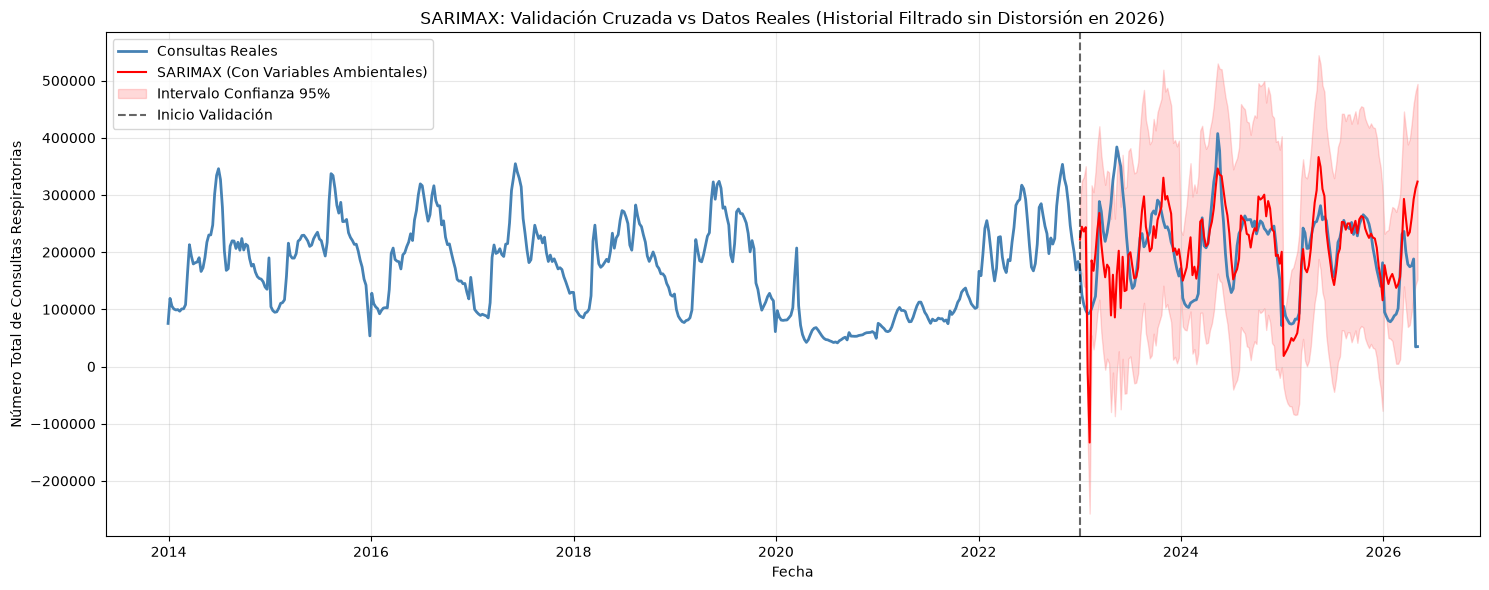

In [73]:
todas_las_preds = pd.concat(predicciones_totales)
todos_los_ic = pd.concat(ic_totales)

plt.figure(figsize=(15, 6))

plt.plot(ts_df.index, ts_df['NumTotal'], label='Consultas Reales', color='steelblue', linewidth=2)

plt.plot(todas_las_preds.index, todas_las_preds, color='red', label='SARIMAX (Con Variables Ambientales)', linewidth=1.5)

plt.fill_between(todos_los_ic.index,
                 todos_los_ic.iloc[:, 0],
                 todos_los_ic.iloc[:, 1], color='red', alpha=0.15, label='Intervalo Confianza 95%')

plt.axvline(x=pd.to_datetime(f"{start_test_year}-01-01"), color='black', linestyle='--', alpha=0.6, label='Inicio Validación')

plt.title('SARIMAX: Validación Cruzada vs Datos Reales (Historial Filtrado sin Distorsión en 2026)')
plt.xlabel('Fecha')
plt.ylabel('Número Total de Consultas Respiratorias')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()